In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
EXPERIMENT_LOCATION = 'logs/experiment4'
all_results = pd.DataFrame()
for folder in os.listdir(EXPERIMENT_LOCATION):
    tmp = pd.read_csv(f"{EXPERIMENT_LOCATION}/{folder}/results.csv").assign(algo = folder)
    all_results = pd.concat([tmp, all_results])

all_results

,Unnamed: 0,timestep,positions,velocities,fuel,rewards,actions,distance_to_target,run,algo
0,0,0,0.025165,0.503309,0.495305,-25.630844,0.939077,4.974835,4,RandomShooting
1,1,1,0.071593,0.928556,0.491004,-25.029011,0.860127,4.928407,4,RandomShooting
2,2,2,0.136494,1.298020,0.486996,-24.296098,0.801505,4.863506,4,RandomShooting
3,3,3,0.205525,1.380618,0.484450,-23.246338,0.509264,4.794475,4,RandomShooting
4,4,4,0.296360,1.816704,0.480257,-22.827416,0.838565,4.703640,4,RandomShooting
...,...,...,...,...,...,...,...,...,...,...
495,95,95,4.985845,-0.060106,0.270539,-0.168290,-0.409988,0.014155,0,CEM
496,96,96,4.981293,-0.091039,0.268353,-0.191523,-0.437234,0.018707,0,CEM
497,97,97,4.979126,-0.043331,0.266501,-0.137533,-0.370267,0.020874,0,CEM
498,98,98,4.978498,-0.012562,0.264582,-0.147774,-0.383812,0.021502,0,CEM


<Axes: xlabel='timestep', ylabel='rewards'>

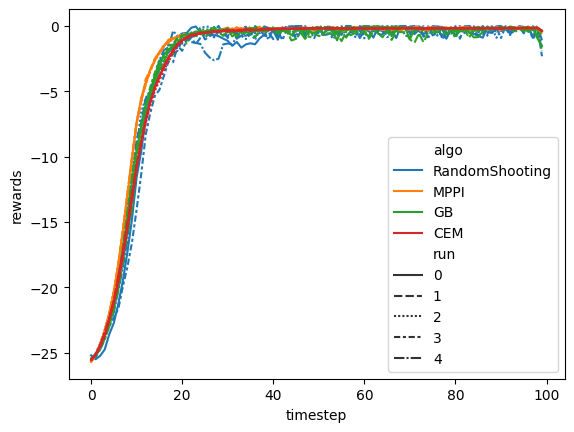

In [4]:
sns.lineplot(
    data=all_results,
    x='timestep',
    y='rewards',
    hue='algo',
    style='run'
)

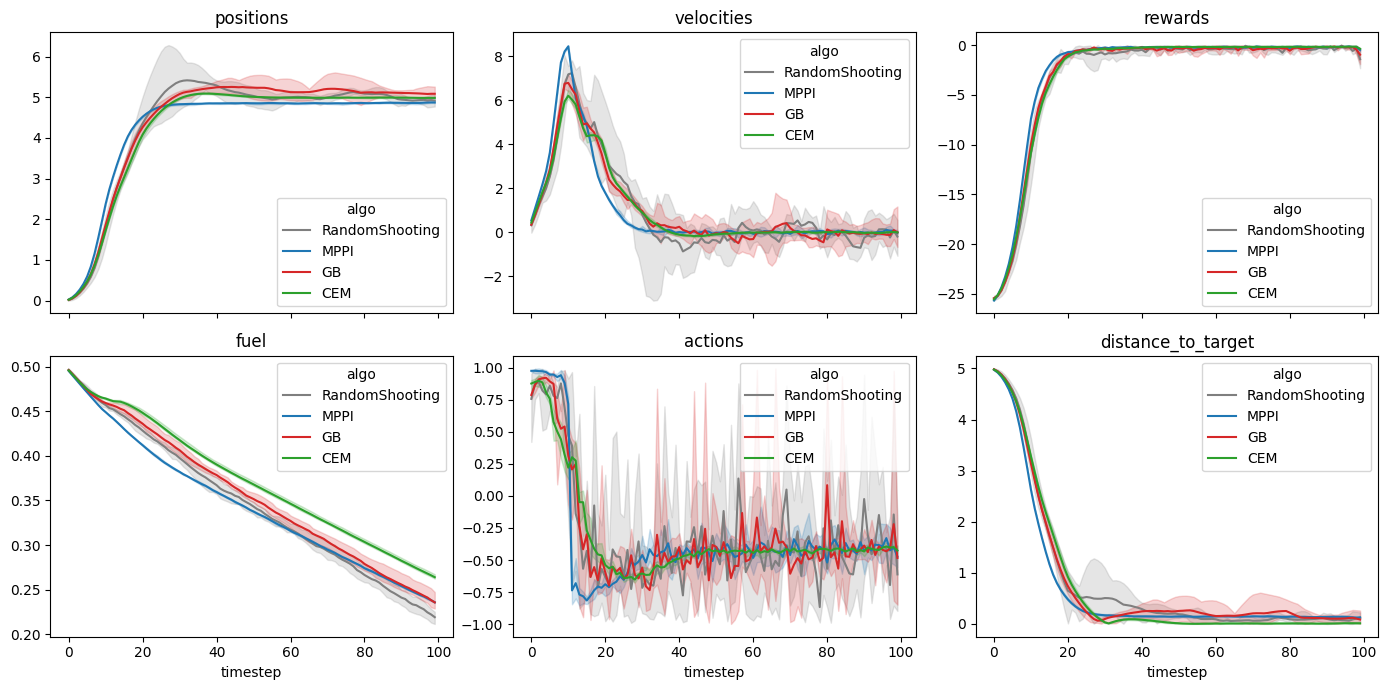

In [20]:
to_plot = all_results.drop('Unnamed: 0', axis=1).melt(id_vars=['algo', 'timestep'])#.query('algo != "GB"')
palette = {
    "RandomShooting": "#7f7f7f",  # neutral gray (baseline)
    "MPPI":           "#1f77b4",  # blue (primary, strong performer)
    "GB":             "#d62728",  # red (gradient-based)
    "CEM":            "#2ca02c",  # green (elite-sampling / evolutionary)
}

fig, ax = plt.subplots(2,3, figsize=(14, 7), sharex=True)
ax = ax.flatten()
cols_to_plot =['positions', 'velocities', 'rewards', 'fuel', 'actions', 'distance_to_target'] 
for i, col in enumerate(cols_to_plot):
    sns.lineplot(
        data=to_plot.query('variable == @col'),
        x = 'timestep',
        y = 'value',
        hue='algo',
        ax=ax[i],
        errorbar=("pi", 100),
        palette=palette
    )
    ax[i].set_title(col)
    ax[i].set(title = col, ylabel="")
plt.tight_layout()
plt.show();

In [6]:
aggregate_results = all_results.groupby(['algo', 'run']).agg({'rewards': 'mean', 'distance_to_target':'mean'})
# aggregate_results['rewards'].boxplot(x='algo')
# aggregate_results['distance_to_target'].plot(kind='bar', title='distance to target')

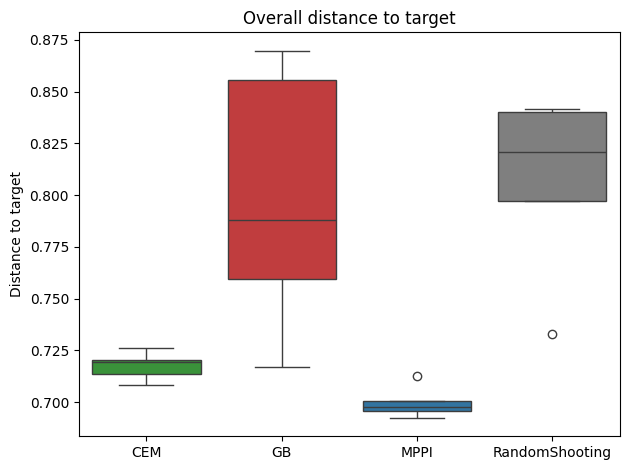

In [21]:
plot = sns.boxplot(
    data=aggregate_results.reset_index(),
    x='algo',
    y='distance_to_target',
    hue='algo',
    palette=palette
)

plot.set(title = "Overall distance to target", ylabel="Distance to target", xlabel="")
plt.tight_layout();
plt.show();

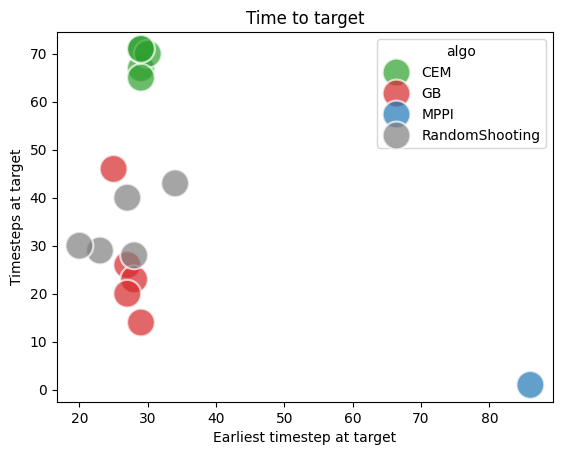

In [22]:
all_results['reach_target'] = (all_results['distance_to_target'] < 0.1)*1
out = (
    all_results
    .groupby(['algo', 'run', 'reach_target'], as_index=False)
    .agg(
        timestep_min=('timestep', 'min'),
        timestep_count=('timestep', 'count')
    )
)


plot = sns.scatterplot(
    data=out.query('reach_target==1'), 
    x='timestep_min', 
    y='timestep_count', 
    hue='algo',
    s = 400,
    alpha = 0.7,
    palette=palette
)

plot.set(title='Time to target', xlabel="Earliest timestep at target", ylabel="Timesteps at target")
plt.show();

(0.0, 1.0)

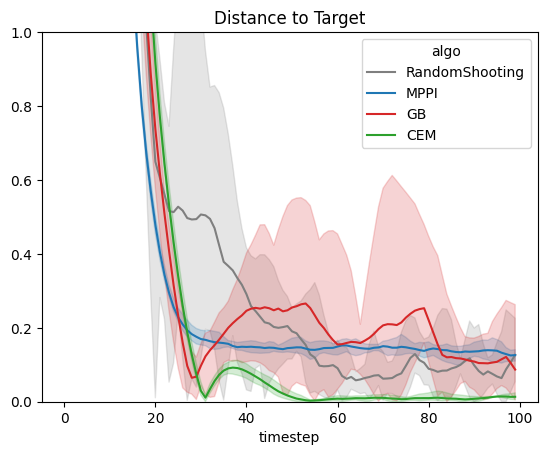

In [24]:
plot = sns.lineplot(
    data=all_results,
    x='timestep',
    y='distance_to_target',
    hue = 'algo',
    errorbar=("pi", 100),
    palette=palette
)

plot.set_title('Distance to Target')
plot.set_ylabel("")
plot.set_ylim(0, 1)
# sns.scatterplot(
#     data=all_results.query('reach_target==1'),
#     x='timestep',
#     y='distance_to_target',
#     hue='algo'
# )